# Plot picks 

This notebook is used to plot the waveforms within a window.
The window is predefined. 

Agentic AI was used in this notebook.

by Hiroto Bito 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from obspy import read
from obspy.core import UTCDateTime
from obspy.clients.fdsn.client import Client
import numpy as np
import os
from tqdm import tqdm

import time

In [2]:
event_df = pd.read_csv('/wd1/hbito_data/data/datasets_all_regions/Cascadia_relocated_catalog_ver_3.csv')
event_df.head()

,Latitude,Longitude,Depth (km),Origin Time (UTC),Uncertainity (km),Horizontal Uncertainity (km),Geometric Std. (km),Detection Value,Num. P,Num. S,RMS Residual (s),Event ID
0,47.22533,-122.16895,56.111,2010-01-01T00:15:17.262282Z,10.223,10.216,0.790,0.680,2,5,1.081,0
1,48.19518,-121.77276,3.820,2010-01-01T00:16:49.375360Z,7.560,3.786,0.140,0.840,25,30,0.985,1
2,47.86208,-122.09903,17.799,2010-01-01T07:18:03.689209Z,5.118,4.807,0.195,0.741,10,18,0.784,2
3,47.96435,-122.91906,21.286,2010-01-01T08:51:56.371091Z,1.899,1.884,0.287,0.756,10,10,0.465,3
4,45.87262,-122.19180,9.822,2010-01-01T16:12:43.838660Z,2.842,2.838,0.229,0.850,20,19,0.657,4


In [3]:
# picks_df = pd.read_csv('/wd1/hbito_data/data/datasets_all_regions/Cascadia_relocated_catalog_picks_ver_3.csv')
# picks_df

In [4]:
assigned_picks_df = pd.read_csv('/wd1/hbito_data/data/datasets_all_regions/Cascadia_updated_catalog_picks_assignment_ver_3.csv')
assigned_picks_df.head(10)

,Unnamed: 0,time_pick,station,phase,timeres,idx,arid,latitude,longitude,depth,Detection Value,time,RMS Residual (s),Num. P,Num. S,picks,slatitude,slongitude,selevation
0,0,2010-01-01T00:15:27.180000Z,UW.PCMD,P,0.049,0,0,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.888962,-122.301483,239.0
1,1,2010-01-01T00:15:37.840400Z,UW.RVW,P,1.264,0,1,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.149750,-122.742996,504.0
2,2,2010-01-01T00:15:33.280000Z,UW.PCMD,S,-0.243,0,2,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.888962,-122.301483,239.0
3,3,2010-01-01T00:15:42.002000Z,UW.GNW,S,2.402,0,3,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.564130,-122.824980,220.0
4,4,2010-01-01T00:15:43.618400Z,PB.B013,S,-0.651,0,4,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.813000,-122.910797,75.3
5,5,2010-01-01T00:15:43.768400Z,PB.B943,S,-0.511,0,5,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.813202,-122.911301,84.2
6,6,2010-01-01T00:15:48.060400Z,UW.BOW,S,-0.263,0,6,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.474831,-123.229301,870.0
7,7,2010-01-01T00:17:04.730000Z,UW.PASS,P,-0.499,1,7,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,48.998299,-122.085197,175.4
8,8,2010-01-01T00:17:05.008400Z,PB.B943,P,-0.252,1,8,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,47.813202,-122.911301,84.2
9,9,2010-01-01T00:17:05.020400Z,UW.BLN,P,0.415,1,9,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,48.006624,-122.972646,601.0


In [5]:
window_after = 120  # seconds after origin time
window_before = 30  # seconds before origin time

In [6]:
path = '/wd1/hbito_data/data/datasets_all_regions/plot_picks_reloc_cog_ver3/'

In [7]:
os.makedirs(path, exist_ok=True)

test

In [8]:
assigned_picks_df.keys()

Index(['Unnamed: 0', 'time_pick', 'station', 'phase', 'timeres', 'idx', 'arid',
       'latitude', 'longitude', 'depth', 'Detection Value', 'time',
       'RMS Residual (s)', 'Num. P', 'Num. S', 'picks', 'slatitude',
       'slongitude', 'selevation'],
      dtype='object')

In [9]:
assigned_picks_df.iloc[0]

Unnamed: 0                                         0
time_pick                2010-01-01T00:15:27.180000Z
station                                      UW.PCMD
phase                                              P
timeres                                        0.049
idx                                                0
arid                                               0
latitude                                    47.13396
longitude                                 -122.09098
depth                                         60.147
Detection Value                                 0.68
time                2010-01-01 00:15:16.204000+00:00
RMS Residual (s)                               1.081
Num. P                                             2
Num. S                                             5
picks                                              7
slatitude                                  46.888962
slongitude                               -122.301483
selevation                                    

In [68]:
# Define the variables in the function

window_before = 30 # in sec
window_after = 120 # in sec
n_picks = 10
client = Client("IRIS")

In [69]:
len(times)

6000

In [76]:
150 * 40

6000

<class 'str'>
2010-01-01 00:15:16.204000+00:00
<class 'str'>
2010-01-01 00:15:16.204000+00:00
<class 'str'>
2010-01-01 00:15:16.204000+00:00
<class 'str'>
2010-01-01 00:15:16.204000+00:00
<class 'str'>
2010-01-01 00:15:16.204000+00:00
<class 'str'>
2010-01-01 00:15:16.204000+00:00
<class 'str'>
2010-01-01 00:15:16.204000+00:00
<class 'str'>
2010-01-01 00:16:49.343000+00:00
<class 'str'>
2010-01-01 00:16:49.343000+00:00
<class 'str'>
2010-01-01 00:16:49.343000+00:00
2 Trace(s) in Stream:
UW.GNW..BHZ  | 2010-01-01T00:14:46.212000Z - 2010-01-01T00:17:16.192000Z | 50.0 Hz, 7500 samples
UW.PASS..BHZ | 2010-01-01T00:16:19.350000Z - 2010-01-01T00:18:49.325000Z | 40.0 Hz, 6000 samples
UW.GNW..BHZ | 2010-01-01T00:14:46.212000Z - 2010-01-01T00:17:16.192000Z | 50.0 Hz, 7500 samples
time [-30.         -29.97999733 -29.95999467 ... 119.95999467 119.97999733
 120.        ]
7500
UW.PASS..BHZ | 2010-01-01T00:16:19.350000Z - 2010-01-01T00:18:49.325000Z | 40.0 Hz, 6000 samples
time [-30.         -29.974

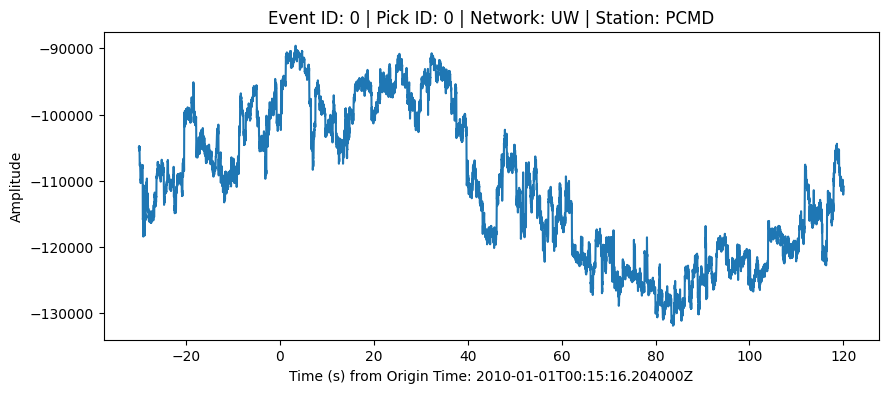

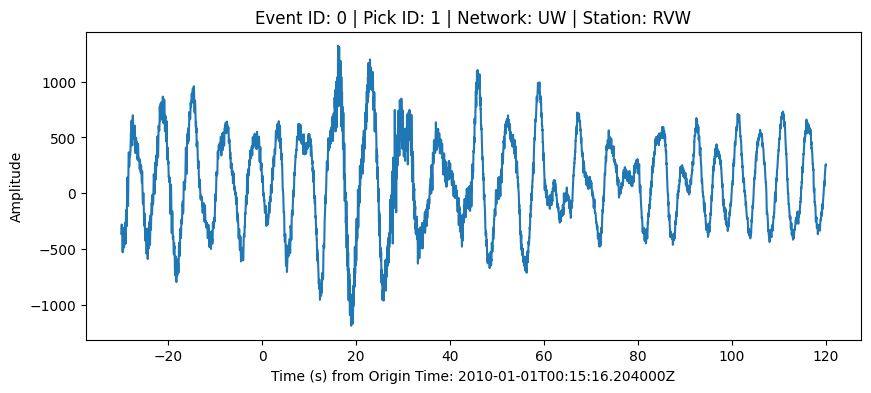

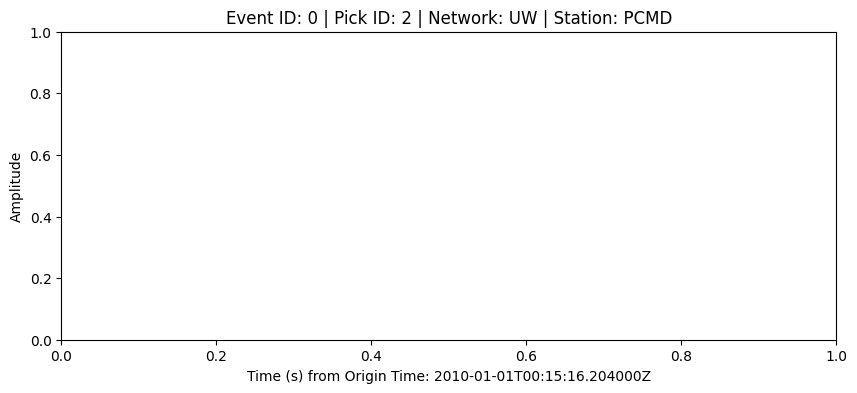

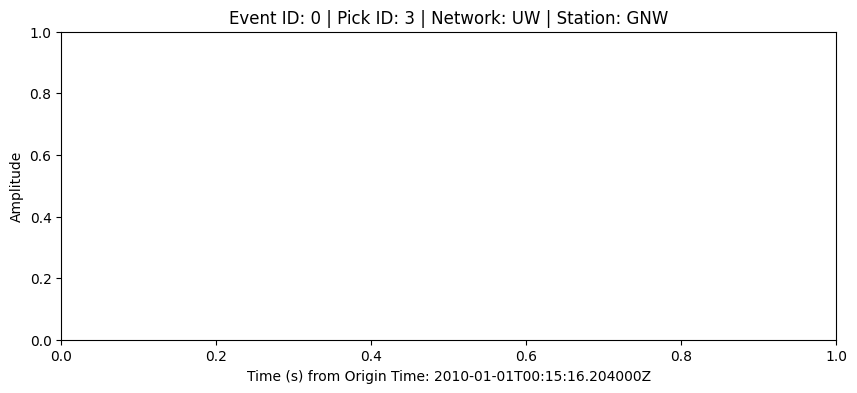

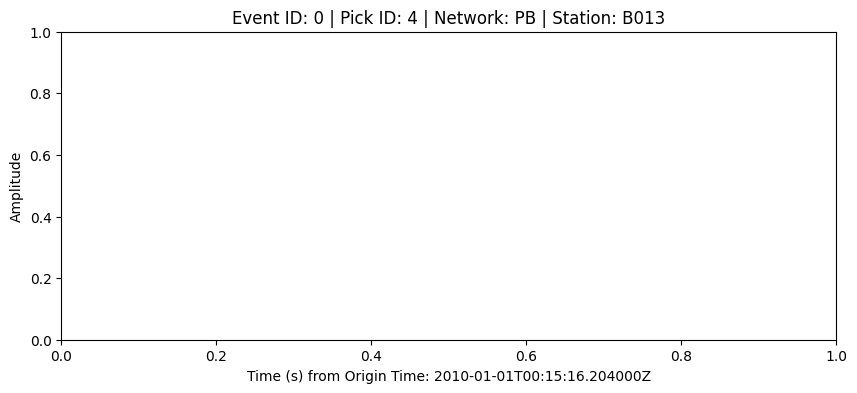

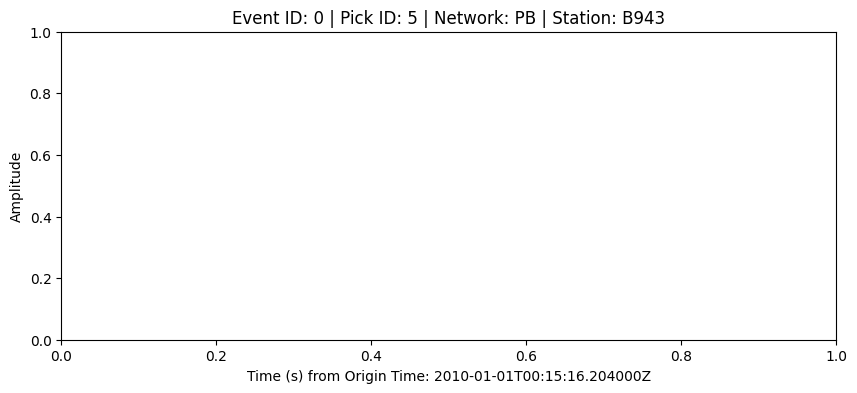

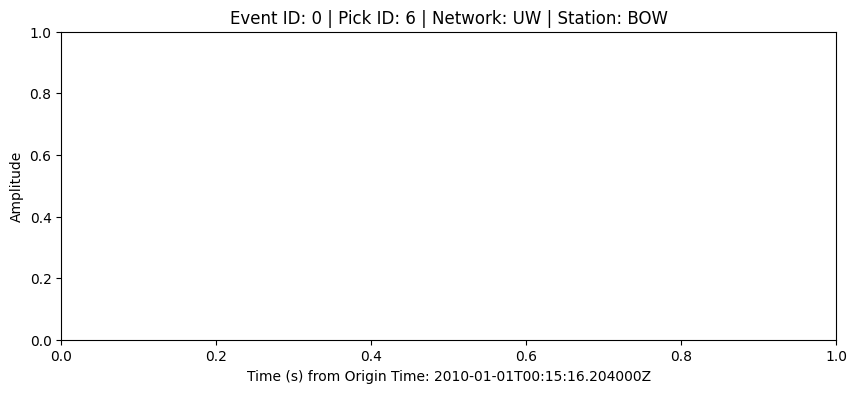

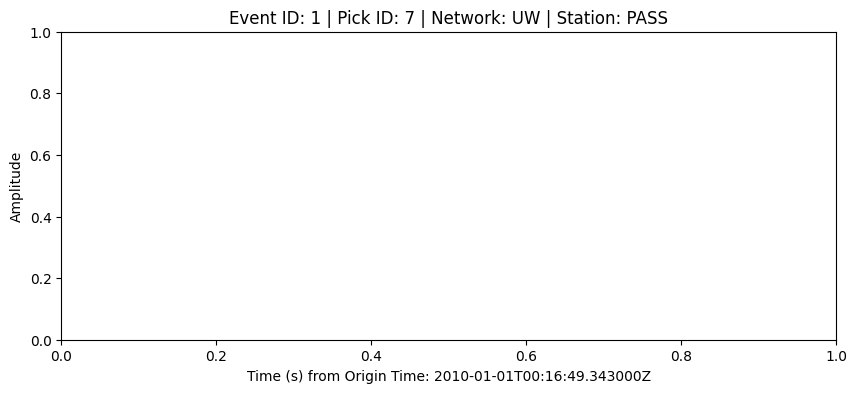

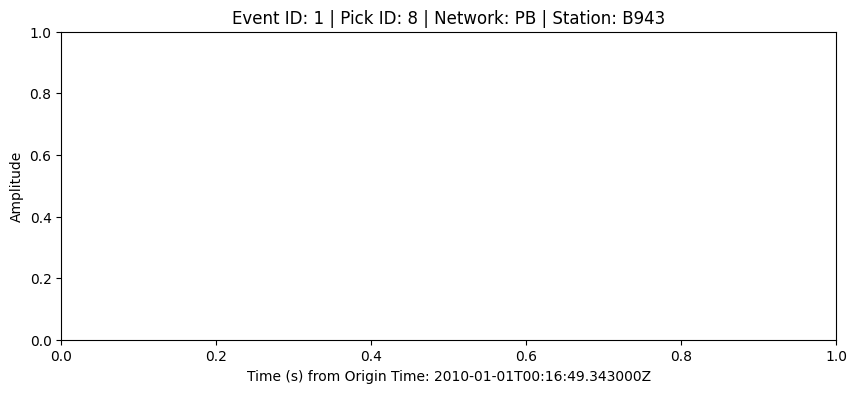

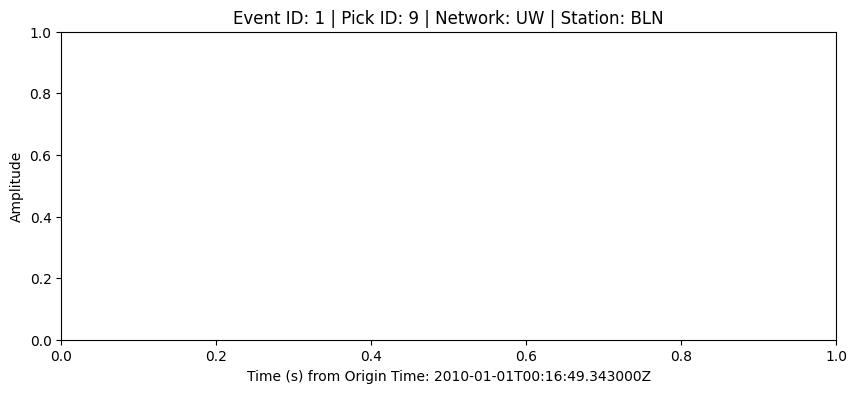

In [73]:
# Prepare bulk request list: (network, station, location, channel, starttime, endtime)
bulk = []
pick_info = []

for i, row in assigned_picks_df.head(n_picks).iterrows():
    event_id = row['idx']
    pick_id = row['arid']
    print(type(row['time']))
    print(row['time'])
    date, _time = row['time'].split(' ')
    datetime_str = date+'T'+_time
    origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly
    latitude = row['latitude']
    longitude = row['longitude']
    depth = row['depth']
    
    # You may need to adjust these fields to match your DataFrame columns
    network = row['station'].split('.')[0].strip()
    station = row['station'].split('.')[1].strip()
    location = '*'
    channel = "BHZ"
    starttime = origin_time - window_before
    endtime = origin_time + window_after
    time_pick = row['time_pick']

    bulk.append((network, station, location, channel, starttime, endtime))
    pick_info.append({
        'event_id': event_id,
        'pick_id': pick_id,
        'origin_time': origin_time,
        'latitude': latitude,
        'longitude': longitude,
        'depth': depth,
        'network': network,
        'station': station,
        'location': location,
        'channel': channel,
        'starttime': starttime,
        'endtime': endtime,
        'time_pick': time_pick
    })

# Request all waveforms in bulk (may take time and may fail for some requests)

time.sleep(0.1)

try:
    st_list = client.get_waveforms_bulk(bulk)
except Exception as e:
    print(f"Bulk request failed: {e}")
    st_list = []

time.sleep(0.1)

print(st_list)

# Plotting
for i, info in enumerate(pick_info):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.set_title(f"Event ID: {info['event_id']} | Pick ID: {info['pick_id']} | Network: {info['network']} | Station: {info['station']}")
    ax.set_xlabel(f"Time (s) from Origin Time: {info['origin_time']}")
    ax.set_ylabel("Amplitude")
    
    if i < len(st_list) and st_list[i]:
        tr = st_list[i]
        print(tr)

        times = np.linspace(-window_before, window_after, tr.stats.npts)
        print('time', times)
        print(len(times))
        # ax.plot(times, tr.data, label=tr.id)
        ax.plot(times, tr.data)
        
        # ax.legend()
    else:
        print(f"No waveform retrieved for {info['network']}.{info['station']} with location={info['location']}, channel={info['channel']}, starttime={info['starttime']}, endtime={info['endtime']}")
        # times = np.linspace(-window_before, window_after, 1000)
        # ax.plot(times, np.zeros_like(times), label="No waveform found")
        # ax.legend()
    

In [ ]:
pick_info

{'event_id': 0,
 'pick_id': 0,
 'origin_time': 2010-01-01T00:15:16.204000Z,
 'latitude': 47.13396,
 'longitude': -122.09098,
 'depth': 60.147,
 'network': 'UW',
 'station': 'PCMD',
 'location': '*',
 'channel': 'BHZ',
 'starttime': 2010-01-01T00:15:46.204000Z,
 'endtime': 2010-01-01T00:17:16.204000Z,
 'time_pick': '2010-01-01T00:15:27.180000Z'}

In [27]:
st_list[0].stats

               network: UW
               station: GNW
              location: 
               channel: BHZ
             starttime: 2010-01-01T00:15:46.212000Z
               endtime: 2010-01-01T00:17:16.192000Z
         sampling_rate: 50.0
                 delta: 0.02
                  npts: 4500
                 calib: 1.0
_fdsnws_dataselect_url: http://service.iris.edu/fdsnws/dataselect/1/query
               _format: MSEED
                 mseed: AttribDict({'dataquality': 'M', 'number_of_records': 21, 'encoding': 'STEIM2', 'byteorder': '>', 'record_length': 512, 'filesize': 15360})

end test

In [117]:
# Function to plot waveforms for the first 100 picks using Obspy bulk request
 
def plot_waveforms_for_picks_bulk(assigned_picks_df, window_before=30, window_after=120, n_picks=100, client_name="IRIS", scaling_factor_vline=0.1):
    client = client_name
    
    # Prepare bulk request list: (network, station, location, channel, starttime, endtime)
    bulk = []
    pick_info = []
    
    for i, row in assigned_picks_df.head(n_picks).iterrows():
        event_id = row['idx']
        pick_id = row['arid']
        print(type(row['time']))
        print(row['time'])
        date, _time = row['time'].split(' ')
        datetime_str = date+'T'+_time
        origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly
        latitude = row['latitude']
        longitude = row['longitude']
        depth = row['depth']
        
        # You may need to adjust these fields to match your DataFrame columns
        network = row['station'].split('.')[0].strip()
        station = row['station'].split('.')[1].strip()
        location = '*'
        channel = "BHZ"
        starttime = origin_time - window_before 
        endtime = origin_time + window_after
        time_pick = row['time_pick']
        time_pick_origin  = UTCDateTime(row['time_pick']) - origin_time
        phase = row['phase']

        bulk.append((network, station, location, channel, starttime, endtime))
        pick_info.append({
            'event_id': event_id,
            'pick_id': pick_id,
            'origin_time': origin_time,
            'latitude': latitude,
            'longitude': longitude,
            'depth': depth,
            'network': network,
            'station': station,
            'location': location,
            'channel': channel,
            'starttime': starttime,
            'endtime': endtime,
            'time_pick': time_pick,
            'time_pick_origin': time_pick_origin,
            'phase': phase
        })
    
    # Request all waveforms in bulk (may take time and may fail for some requests)

    time.sleep(0.1)

    try:
        st_list = client.get_waveforms_bulk(bulk)
    except Exception as e:
        print(f"Bulk request failed: {e}")
        st_list = []

    time.sleep(0.1)

    print(st_list)

    # Parameters to process waveforms
    new_sampling_rate = 100 # in Hz
    highpass_freq = 4 # in Hz

    
    # Plotting
    for i, info in enumerate(pick_info):
        print(i)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.set_title(f"Event ID: {info['event_id']} | Pick ID: {info['pick_id']} | Network: {info['network']} | Station: {info['station']} | Phase: {info['phase']}")
        ax.set_xlabel(f"Time (s) from Origin Time: {info['origin_time']}")
        ax.set_ylabel("Amplitude")
        
        if i < len(st_list) and st_list[i]:
            tr = st_list[i]
            print(tr)

            # Resample
            tr.resample(new_sampling_rate)
                
            # Apply highpass filter
            tr.filter('highpass', freq=highpass_freq)
                

            times = np.linspace(-window_before, window_after, tr.stats.npts)
            data = tr.data

            # Parameters to draw the vertical lines to indicate picks
            ymax = np.max(np.abs(data))*scaling_factor_vline
            ymin = (-1) * np.max(np.abs(data))*scaling_factor_vline

            print('time', times)
            # ax.plot(times, tr.data, label=tr.id)
            ax.plot(times, data)
            ax.vlines(time_pick, ymin, ymax, color='k', linestyles='solid')
            # ax.legend()
        else:
            print(f"No waveform retrieved for {info['network']}.{info['station']} with location={info['location']}, channel={info['channel']}, starttime={info['starttime']}, endtime={info['endtime']}")
            # times = np.linspace(-window_before, window_after, 1000)
            # ax.plot(times, np.zeros_like(times), label="No waveform found")
            # ax.legend()
        
        # Annotate event info
        info_text = (f"Origin Time: {info['origin_time']}\n"
                     f"Latitude: {info['latitude']}\n"
                     f"Longitude: {info['longitude']}\n"
                     f"Depth: {info['depth']}")
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.98, 0.98, info_text, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='right', bbox=props)
        plt.tight_layout()
        plt.show()
        fig.savefig(path+f"waveform_plot_{info['event_id']}_{info['pick_id']}.png")
        plt.close(fig)
        time.sleep(0.1)


In [118]:
# Define the variables in the function

window_before = 30 # in sec
window_after = 120 # in sec
n_picks = 10
client = Client("IRIS")
scaling_factor_vline = 0.3

<class 'str'>
2010-01-01 00:15:16.204000+00:00
<class 'str'>
2010-01-01 00:15:16.204000+00:00
<class 'str'>
2010-01-01 00:15:16.204000+00:00
<class 'str'>
2010-01-01 00:15:16.204000+00:00
<class 'str'>
2010-01-01 00:15:16.204000+00:00
<class 'str'>
2010-01-01 00:15:16.204000+00:00
<class 'str'>
2010-01-01 00:15:16.204000+00:00
<class 'str'>
2010-01-01 00:16:49.343000+00:00
<class 'str'>
2010-01-01 00:16:49.343000+00:00
<class 'str'>
2010-01-01 00:16:49.343000+00:00
2 Trace(s) in Stream:
UW.GNW..BHZ  | 2010-01-01T00:14:46.212000Z - 2010-01-01T00:17:16.192000Z | 50.0 Hz, 7500 samples
UW.PASS..BHZ | 2010-01-01T00:16:19.350000Z - 2010-01-01T00:18:49.325000Z | 40.0 Hz, 6000 samples
0
UW.GNW..BHZ | 2010-01-01T00:14:46.212000Z - 2010-01-01T00:17:16.192000Z | 50.0 Hz, 7500 samples
time [-30.         -29.98999933 -29.97999867 ... 119.97999867 119.98999933
 120.        ]


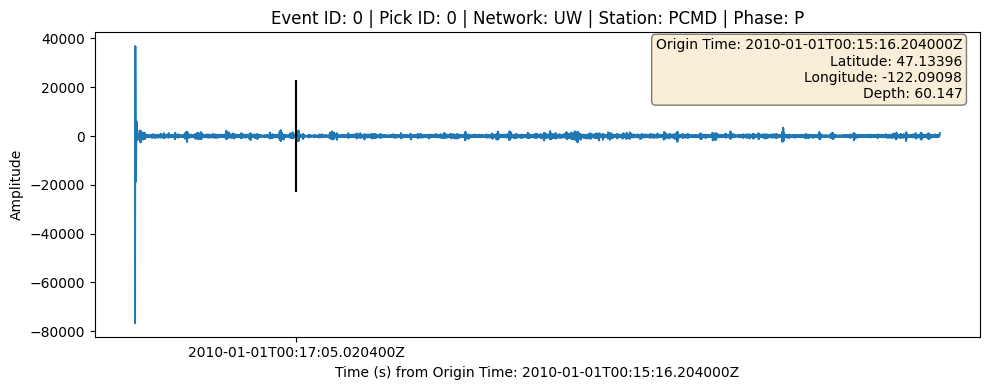

1
UW.PASS..BHZ | 2010-01-01T00:16:19.350000Z - 2010-01-01T00:18:49.325000Z | 40.0 Hz, 6000 samples
time [-30.         -29.98999933 -29.97999867 ... 119.97999867 119.98999933
 120.        ]


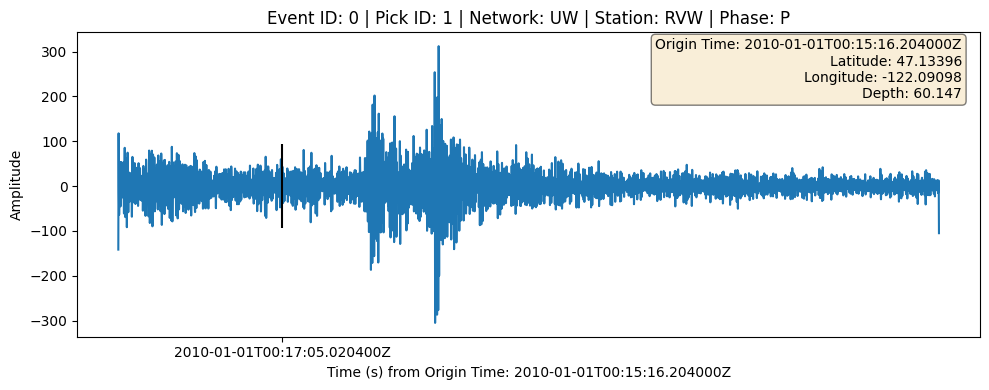

2
No waveform retrieved for UW.PCMD with location=*, channel=BHZ, starttime=2010-01-01T00:14:46.204000Z, endtime=2010-01-01T00:17:16.204000Z


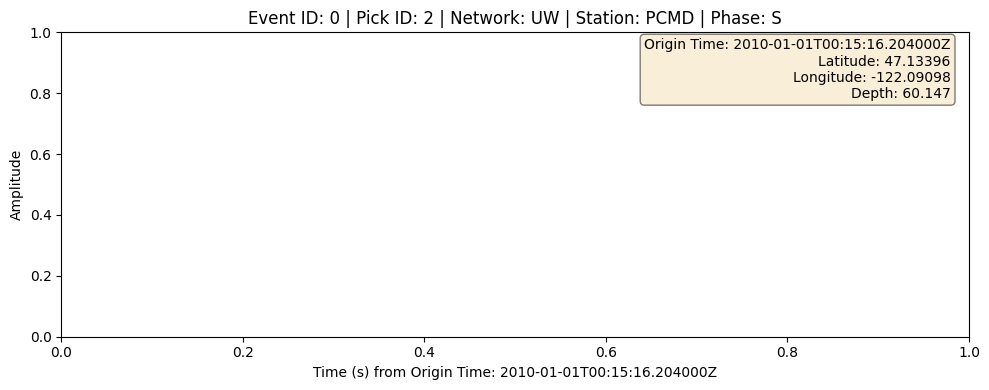

3
No waveform retrieved for UW.GNW with location=*, channel=BHZ, starttime=2010-01-01T00:14:46.204000Z, endtime=2010-01-01T00:17:16.204000Z


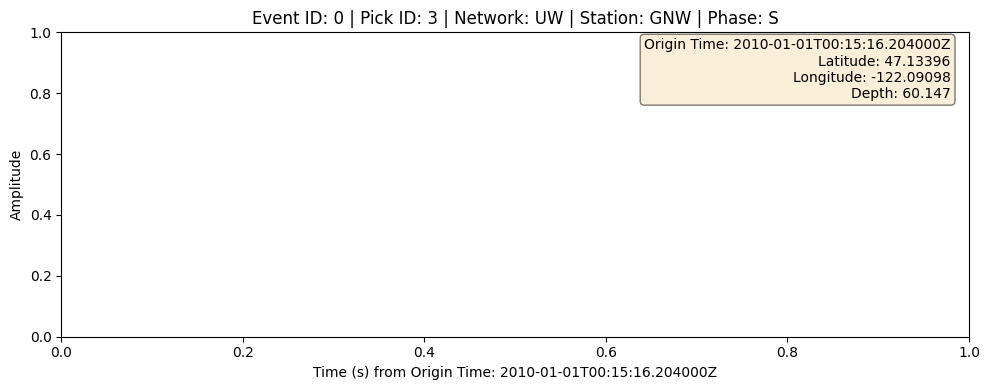

4
No waveform retrieved for PB.B013 with location=*, channel=BHZ, starttime=2010-01-01T00:14:46.204000Z, endtime=2010-01-01T00:17:16.204000Z


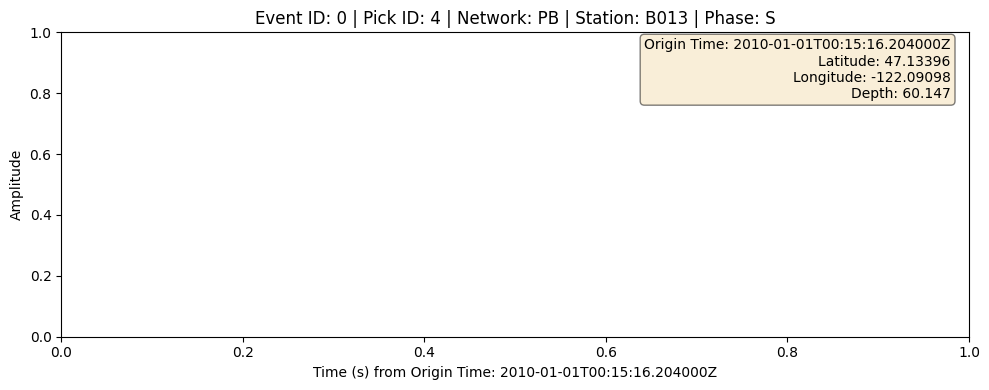

5
No waveform retrieved for PB.B943 with location=*, channel=BHZ, starttime=2010-01-01T00:14:46.204000Z, endtime=2010-01-01T00:17:16.204000Z


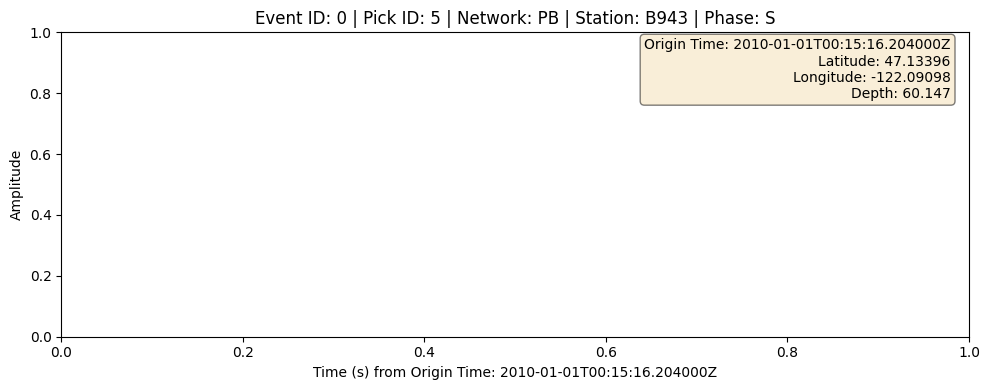

6
No waveform retrieved for UW.BOW with location=*, channel=BHZ, starttime=2010-01-01T00:14:46.204000Z, endtime=2010-01-01T00:17:16.204000Z


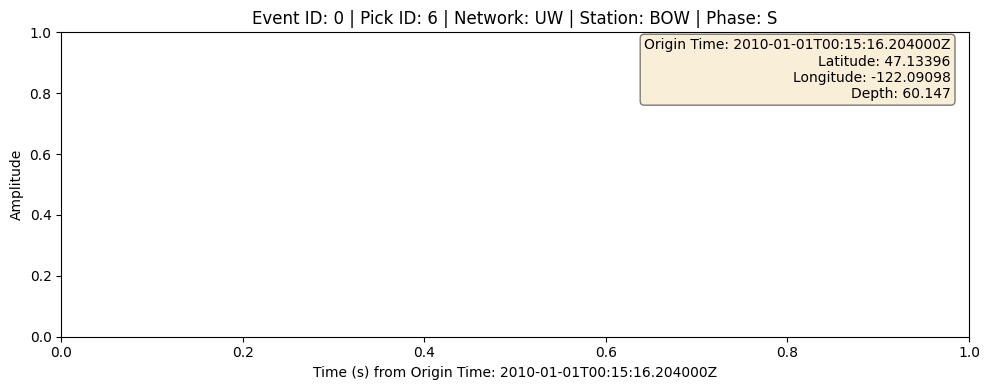

7
No waveform retrieved for UW.PASS with location=*, channel=BHZ, starttime=2010-01-01T00:16:19.343000Z, endtime=2010-01-01T00:18:49.343000Z


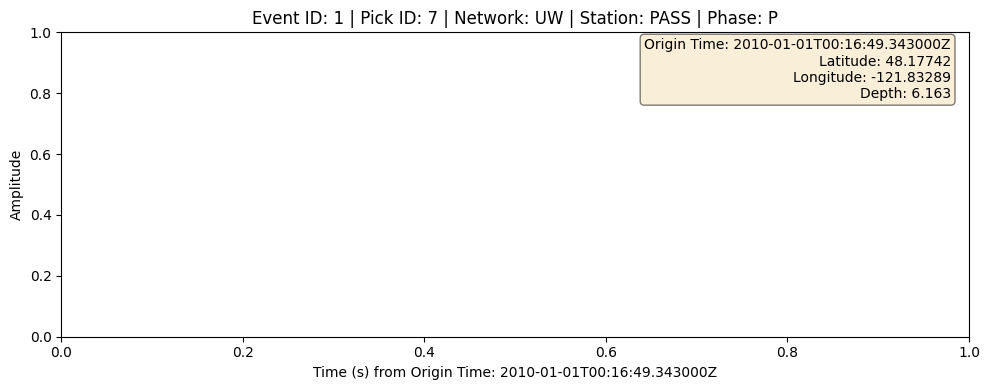

8
No waveform retrieved for PB.B943 with location=*, channel=BHZ, starttime=2010-01-01T00:16:19.343000Z, endtime=2010-01-01T00:18:49.343000Z


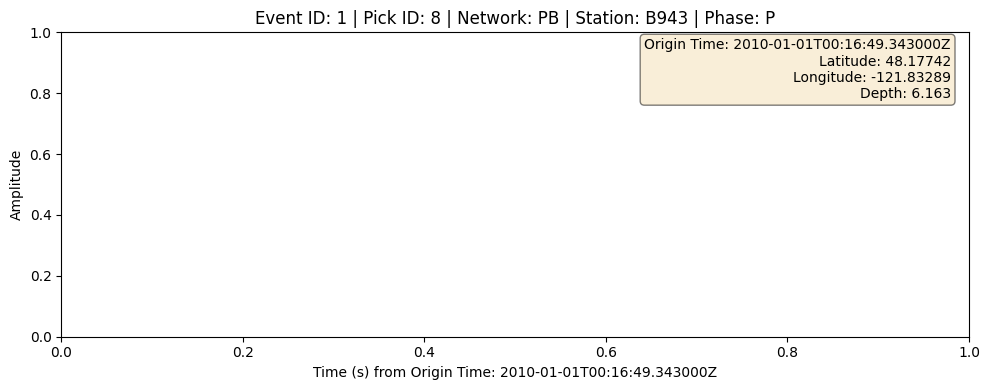

9
No waveform retrieved for UW.BLN with location=*, channel=BHZ, starttime=2010-01-01T00:16:19.343000Z, endtime=2010-01-01T00:18:49.343000Z


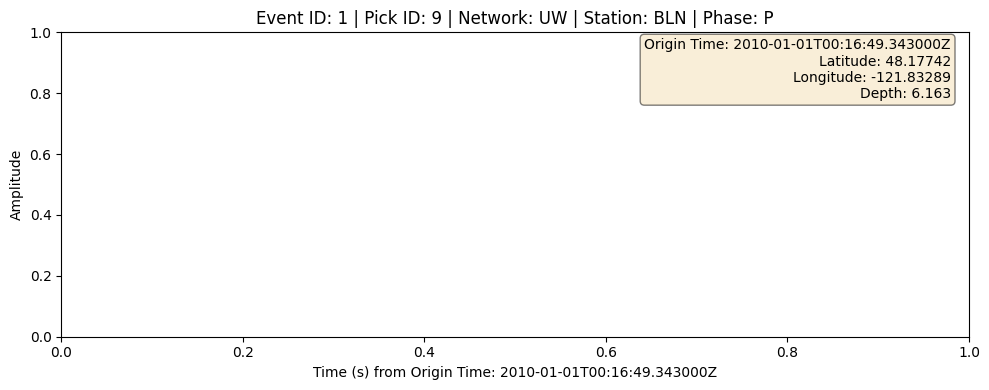

In [119]:
# Run the plotting function (set n_picks=10 for quick test, 100 for full)

plot_waveforms_for_picks_bulk(assigned_picks_df, window_before, window_after, n_picks, client, scaling_factor_vline)


test

In [16]:
# Test whether UTCDateTime doesn't accept a string as an input

UTCDateTime('2010-01-01T00:15:16.204000+00:00')

2010-01-01T00:15:16.204000Z

In [17]:
# Test whether UTCDateTime doesn't accept a string as an input

UTCDateTime('2010-01-01 00:15:16.204000+00:00')

TypeError: an integer is required (got type str)

In [14]:
UTCDateTime("1970,001,12:23:34")

1970-01-01T12:23:34.000000Z

In [ ]:
UTCDateTime('2019-09-18T18:23:10.22-01')  # time zone is UTC-1

2019-09-18T19:23:10.220000Z

In [18]:
datetime_str = '2010-01-01 00:15:16.204000+00:00'


In [22]:
date, time = datetime_str.split(' ')
date

'2010-01-01'

In [23]:
time

'00:15:16.204000+00:00'

In [25]:
print(date+'T'+time)

2010-01-01T00:15:16.204000+00:00


end test